# Expert Labels

In [1]:
import scripts
import numpy as np

In [2]:
theme = ['#0283F8', '#0078F3', '#3369E8', '#605BDA', "#7D49CB",
          "#9331B7", "#A918A8", "#C4009A", "#DA008B", "#EA007B",
          "#F7006A", "#FF0059"]

In [3]:
import sys
import os
import warnings
from contextlib import contextmanager

@contextmanager
def suppress_stdout_stderr():
    """A context manager that redirects stdout and stderr to devnull"""
    # Save the original stdout and stderr
    original_stdout = sys.stdout
    original_stderr = sys.stderr
    
    # Open the null device
    with open(os.devnull, 'w') as devnull:
        # Redirect stdout and stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield # This is where the code inside the 'with' block will run
        finally:
            # IMPORTANT: Always restore the original streams
            sys.stdout = original_stdout
            sys.stderr = original_stderr

import csv
import os

def append_dict_to_csv(csv_filepath, data_dict):
    """
    Appends a dictionary as a new row to a CSV file.

    - If the CSV file does not exist, it will be created, and the
      dictionary keys will be used as the header row.
    - If the CSV file exists, the dictionary values are appended
      as a new row. The keys are assumed to match the header.

    Args:
        csv_filepath (str): The path to the CSV file.
        data_dict (dict): The dictionary to write to the CSV.
    """
    # Check if the file exists to determine if we need to write the header
    file_exists = os.path.exists(csv_filepath)

    # Use 'a' mode for appending, which creates the file if it doesn't exist.
    # newline='' is critical to prevent blank rows from being written.
    with open(csv_filepath, 'a', newline='', encoding='utf-8') as f:
        # The fieldnames are the dictionary keys.
        # It's important that all dictionaries you write have the same keys.
        fieldnames = data_dict.keys()
        
        # Create a DictWriter object
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        # If the file is new, write the header row
        if not file_exists:
            writer.writeheader()

        # Write the dictionary as a new row
        writer.writerow(data_dict)
        
def append_df_to_csv(csv_filepath, df, index=False):
    """
    Appends a pandas DataFrame to a CSV file.

    - If the CSV file does not exist, it's created, and the DataFrame's
      column names are used as the header.
    - If the CSV file exists, the DataFrame's data is appended without
      writing a new header.

    Args:
        csv_filepath (str): The path to the CSV file.
        df (pd.DataFrame): The DataFrame to append.
        index (bool): Write DataFrame index as a column. Defaults to False.
    """
    # Check if the file exists to determine if the header needs to be written.
    header = not os.path.exists(csv_filepath)

    # Use pandas to_csv function with mode 'a' (append)
    # and the header parameter controlled by file existence.
    df.to_csv(
        csv_filepath, 
        mode='a', 
        header=header, 
        index=index,
        encoding='utf-8'
    )

In [4]:
# Load the data
def load_dataset(dataset="adult",expert_accuracy=0.75,seed=42):
    if dataset=="adult":
        df,y,feature_names = scripts.datasets.adult_load_and_preprocess()
    elif dataset== "plant":
        df,y,feature_names = scripts.datasets.plant_load_and_preprocess()
    elif dataset=="telescope":
        df,y,feature_names = scripts.datasets.telescope_load_and_preprocess()
    elif dataset=="wine":
        df,y,feature_names = scripts.datasets.wine_load_and_preprocess()
    elif dataset=="broward":
        return load_broward_dataset()
    elif dataset=="diabetes":
        df,y,feature_names = scripts.datasets.diabetes_load_and_preprocess()
    else:
        print("ERROR: dataset has to be one of [adult, plant,wine]")
        return
            
    np.random.seed(seed)
    feature_weights = {feature: [np.random.randint(0,2), 0] for feature in feature_names}
    
    expert = scripts.expert.simulate_expert(
        X_processed=df,
        y_true=y,
        feature_weights_config=feature_weights,
        target_fnr=1-expert_accuracy, 
        target_fpr=1-expert_accuracy,
        expert_alpha=30,
        expert_seed=seed
    )
    
    human_predictions = expert.predict(df,y)
    dataset = scripts.datasets.Dataset(df.values,y,human_predictions,random_seed=seed) #put seed here too ma man
    return expert, dataset, feature_names

In [5]:
import torch
from defer.helpers.metrics import *
from defer.networks.linear_net import *
from defer.networks.non_linear_net import *
import torch.optim as optim
from defer.methods.realizable_surrogate import *
from defer.baselines.lce_surrogate import *
from defer.baselines.one_v_all import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import os

def train_l2d_model(dataset, expert,method = "realizable_surrogate"):
    # Set up model training parameters
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    optimizer = optim.Adam
    scheduler = None
    lr = 1e-2
    total_epochs = 100
    # Create and train model
    model = NonLinearNet(dataset.d, 3).to(device)  # positive, negative, and defer
    # Instantiate method
    if method=="realizable_surrogate":
        L2D = RealizableSurrogate(1, 300, model, device, True)
    elif method== "crossentropy_surrogate": #lce
        L2D = LceSurrogate(1, 300, model, device)
    elif method== "one_vs_all":
        L2D = OVASurrogate(1, 300, model, device)
    else:
        print("Model has to be one of: realizable_surrogate, crossentropy_surrogate or one_vs_all")
        return None, {}, None, []
    L2D.fit_hyperparam(
        dataset.data_train_loader,
        dataset.data_val_loader,
        dataset.data_test_loader,
        epochs=total_epochs,
        optimizer=optimizer,
        scheduler=scheduler,
        lr=lr,
        verbose=False,
        test_interval=5,
    )
    # Get metrics
    metrics = compute_deferral_metrics(L2D.test(dataset.data_test_loader))
    factual_df, factuals = scripts.utils.build_factual_df(L2D,dataset,expert,defer_only=True)
    return L2D, metrics, factual_df, factuals

In [88]:

def obtain_counterfactuals_and_basins(l2d,factuals,factual_df,metrics,expert):
    perturbations, counter_df = scripts.counterfactual.find_defer_counterfactuals_parallel(
        model=l2d.model,
        test_x=factuals,
        threshold_rej=0,
        n_jobs=-1 # Use all available cores
    )
    
    #counter_df = scripts.utils.probe_counterfactuals(counter_df,perturbations,factuals,expert,l2d)
    counter_df, neighborhood_df = probe_counterfactuals_and_neighborhoods(counter_df,perturbations,factuals,expert,l2d)
    df_merged = factual_df.join(counter_df[["cfs_entropy","cfs_expected_expert_err"]],how="inner")
    
    isTypeI = df_merged["entropy"] > df_merged["cfs_entropy"]
    isTypeII = df_merged["cfs_expected_expert_err"] > df_merged["expected_expert_err"]
    #model_was_correct = df_merged["model_pred"] == df_merged["label"]
    #expert_was_correct = df_merged["expert_pred"] == df_merged["label"]
    
    metrics["n_type1"] = np.sum(isTypeI)
    metrics["n_type2"] = np.sum(isTypeII)
    metrics["n_only_type1"] = np.sum(isTypeI & ~isTypeII)
    metrics["n_only_type2"] = np.sum(isTypeII & ~isTypeI)
    metrics["n_defer"] = df_merged.shape[0]
    return metrics,df_merged,neighborhood_df, perturbations

import numpy as np
import torch
import pandas as pd
from typing import Tuple

# Assume 'evaluate' and 'expert_predict_proba' functions exist and are vectorized.
# e.g., def evaluate(model, inputs_tensor): -> (defer_scores, class_probs, predicted_classes)
# e.g., def expert_predict_proba(inputs_array, expert_model): -> expert_error_probabilities_array

def probe_counterfactuals_and_neighborhoods(
    counter_df: pd.DataFrame,
    perturbations: torch.Tensor,
    factuals: torch.Tensor,
    expert,
    l2d,
    num_neighborhood_samples: int = 100,
    noise_level: float = 0.05,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Analyzes counterfactuals and returns raw data from their local neighborhoods.

    This function performs two main tasks:
    1.  Calculates the machine uncertainty (entropy) and expected expert error for
        each exact counterfactual found.
    2.  For each counterfactual, it generates a "cloud" of nearby points by adding
        random noise and computes the same metrics for each point in the cloud.

    Args:
        counter_df (pd.DataFrame): DataFrame with results from a counterfactual search.
                                   Must have 'sample_index' and 'defer_cf_index' columns.
        perturbations (torch.Tensor): The full set of perturbations found by the search.
        factuals (torch.Tensor): The original factual instances.
        expert: The trained expert model or simulator.
        l2d: The trained L2D model object.
        num_neighborhood_samples (int): The number of noisy samples to generate around each counterfactual.
        noise_level (float): The standard deviation of the Gaussian noise to add.

    Returns:
        A tuple of two DataFrames:
        - cf_metrics_df (pd.DataFrame): A copy of the input `counter_df` (for valid CFs)
          with added columns for the metrics of the exact counterfactual:
            - cfs_entropy
            - cfs_expected_expert_err
        - neighborhood_df (pd.DataFrame): A new DataFrame containing the raw data for all
          generated neighborhood points, with columns:
            - cf_index: The index from `cf_metrics_df` to link back to the parent CF.
            - distance_to_cf: L2 distance from this random point to its parent CF.
            - neighbor_entropy: The entropy of this random point.
            - neighbor_expected_expert_err: The expected expert error of this random point.
    """
    temp = counter_df.dropna(subset=["defer_cf_index"]).copy()
    if temp.empty:
        # Return the original df and an empty df for neighborhood data
        return counter_df, pd.DataFrame(columns=[
            "cf_index", "distance_to_cf", "neighbor_entropy", "neighbor_expected_expert_err"
        ])

    # === Part 1: Evaluate the exact counterfactuals ===
    cf_indices = temp["defer_cf_index"].astype(int)
    counterfactuals = np.array(
        [factuals[i].detach().numpy() + perturbations[j].flatten().numpy() for i,j in zip(temp['sample_index'],temp["defer_cf_index"])]
    )
    _, class_probs, _ = scripts.utils.evaluate(l2d.model, torch.Tensor(counterfactuals))
    expert_error_probabilities = scripts.utils.expert_predict_proba(counterfactuals, expert)

    temp["cfs_entropy"] = -np.sum(class_probs * np.log(class_probs + 1e-9), axis=1)
    temp["cfs_expected_expert_err"] = np.sum(expert_error_probabilities * class_probs, axis=1)
    
    # The first return dataframe is now ready.
    cf_metrics_df = temp

    # === Part 2: Generate and evaluate the neighborhood points ===
    num_cfs = len(counterfactuals)
    
    # Repeat each counterfactual to prepare for vectorized noise addition
    counterfactuals_repeated = np.repeat(counterfactuals, num_neighborhood_samples, axis=0)

    # Generate Gaussian noise for all samples at once
    # The noise vectors themselves are the difference between the neighbor and the CF
    noise_vectors = np.random.normal(loc=0.0, scale=noise_level, size=counterfactuals_repeated.shape)
    neighborhood_samples = counterfactuals_repeated + noise_vectors

    # Evaluate all neighborhood samples in a single vectorized batch
    _, neighbor_class_probs, _ = scripts.utils.evaluate(l2d.model, torch.Tensor(neighborhood_samples))
    neighbor_expert_error_probs = scripts.utils.expert_predict_proba(neighborhood_samples, expert)

    # Calculate metrics for each individual neighborhood point
    neighbor_entropy = -np.sum(neighbor_class_probs * np.log(neighbor_class_probs + 1e-9), axis=1)
    neighbor_exp_err = np.sum(neighbor_expert_error_probs * neighbor_class_probs, axis=1)
    
    # Calculate the L2 distance of each noise vector
    distances = np.linalg.norm(noise_vectors, axis=1)
    
    # Create an index to link each neighborhood point back to its parent counterfactual
    parent_cf_indices = np.repeat(cf_metrics_df.index, num_neighborhood_samples)

    # === Part 3: Assemble the raw neighborhood data DataFrame ===
    neighborhood_df = pd.DataFrame({
        "cf_index": parent_cf_indices,
        "distance_to_cf": distances,
        "neighbor_entropy": neighbor_entropy,
        "neighbor_expected_expert_err": neighbor_exp_err
    })

    return cf_metrics_df, neighborhood_df


Running: plant using crossentropy_surrogate with seed 1754066390...


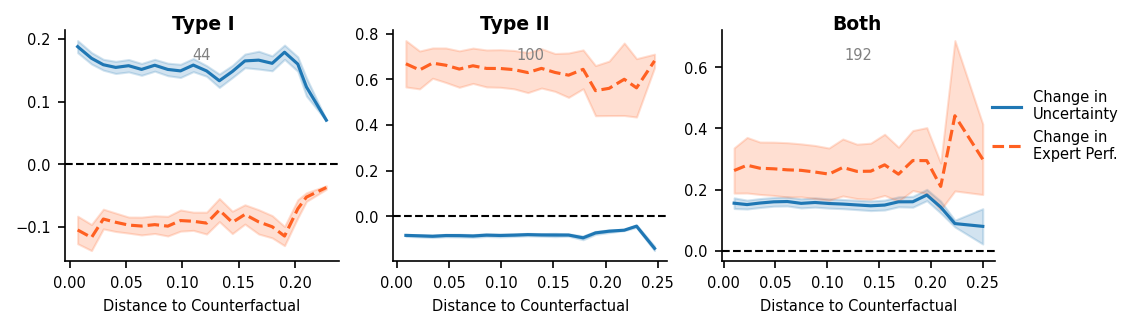

In [251]:
for method in ["crossentropy_surrogate"]: #"crossentropy_surrogate","one_vs_all"
    seed = int(time.time())
    dataset_list = ["plant",] #"adult","plant","wine"
    i=0
    while i < len(dataset_list):
        dataset_name=dataset_list[i]
        print(f"Running: {dataset_name} using {method} with seed {seed}...")
        with suppress_stdout_stderr():
            expert, dataset, feature_names = load_dataset(dataset=dataset_name, expert_accuracy=0.75, seed=seed)
            RS, metrics, factual_df, factuals = train_l2d_model(dataset, expert,method = method)
        if len(factuals)==0: # Or `if factuals.empty:` for pandas DataFrames
            print(f"--> No factuals found. Changing seed and retrying for dataset={dataset_list}...")
            seed = int(time.time()) # Change the seed and try again
            continue
        with suppress_stdout_stderr():
            metrics,df_merged,neighbourhood_df, perturbations = obtain_counterfactuals_and_basins(RS, factuals,factual_df, metrics, expert)
        i+=1
        
        
        # --- Step 1: Ensure Types are Classified (from previous step) ---
        is_type_i = df_merged['entropy'] > df_merged['cfs_entropy']
        is_type_ii = df_merged['cfs_expected_expert_err'] > df_merged['expected_expert_err']
        df_merged['deferral_type'] = 'None'
        df_merged.loc[is_type_i, 'deferral_type'] = 'Type I'
        df_merged.loc[is_type_ii, 'deferral_type'] = 'Type II'
        df_merged.loc[is_type_i & is_type_ii, 'deferral_type'] = 'Mixed'
        # For this analysis, we want the pure types
        df_merged['type_I_only'] = is_type_i & (~is_type_ii)
        df_merged['type_II_only'] = is_type_ii & (~is_type_i)


        mosaic = """
        ABC
        """
        fig, ax = plt.subplot_mosaic(mosaic, figsize=(8, 2),dpi=150)

        # --- Generate the plots ---
        plot_aggregate_robustness(df_merged, neighbourhood_df, 'type_I_only', ax=ax["A"],pad_title=True)
        #plot_aggregate_robustness(df_merged, neighbourhood_df, 'type_i', ax=ax["B"])
        ax['A'].tick_params(axis='both', labelsize=7)
        ax['B'].tick_params(axis='both', labelsize=7)
        ax['C'].tick_params(axis='both', labelsize=7)
        plot_aggregate_robustness(df_merged, neighbourhood_df, 'type_II_only', ax=ax["B"],pad_title=True)
        plot_aggregate_robustness(df_merged, neighbourhood_df, 'mixed', ax=ax["C"],pad_title=True)

        # Create shared legend
        plt.plot([], [], color='#1F77B4', label="Change in\nUncertainty")
        plt.plot([], [], color='#FF6021',linestyle="--", label="Change in\nExpert Perf.")
        plt.legend(frameon=False, bbox_to_anchor=(1.5, 0.8), fontsize=7)

        # Row annotations (left side)
        fig.text(0.24, 0.9, 'Type I', va='center', ha='center', 
                 fontsize=9, fontweight='bold')
        fig.text(0.5, 0.9, 'Type II', va='center', ha='center', 
                 fontsize=9, fontweight='bold')
        fig.text(0.785, 0.9, 'Both', ha='center', va='center', 
                 fontsize=9, fontweight='bold')

        #plt.tight_layout()
        plt.savefig(f"results/robustness_{method}_{dataset_name}.pdf",bbox_inches = 'tight')
        plt.show()

In [ ]:
#realizable_surr [wine.plant]
#crossentropy_surr: [plant]

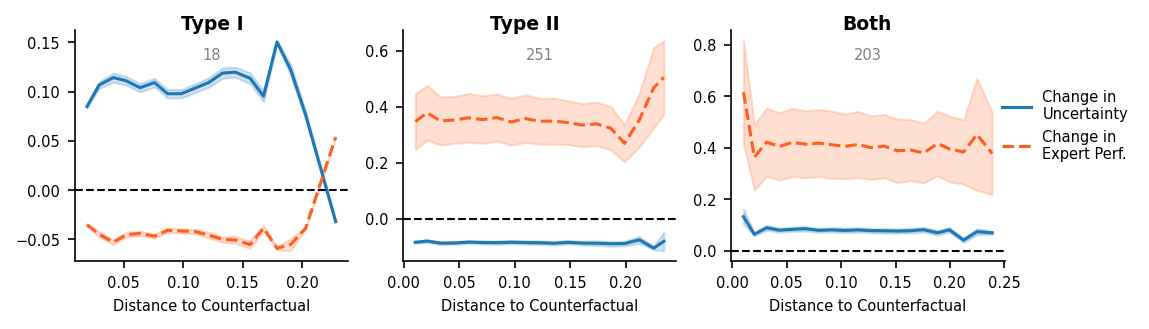

In [246]:

# --- Step 1: Ensure Types are Classified (from previous step) ---
is_type_i = df_merged['entropy'] > df_merged['cfs_entropy']
is_type_ii = df_merged['cfs_expected_expert_err'] > df_merged['expected_expert_err']
df_merged['deferral_type'] = 'None'
df_merged.loc[is_type_i, 'deferral_type'] = 'Type I'
df_merged.loc[is_type_ii, 'deferral_type'] = 'Type II'
df_merged.loc[is_type_i & is_type_ii, 'deferral_type'] = 'Mixed'
# For this analysis, we want the pure types
df_merged['type_I_only'] = is_type_i & (~is_type_ii)
df_merged['type_II_only'] = is_type_ii & (~is_type_i)


mosaic = """
ABC
"""
fig, ax = plt.subplot_mosaic(mosaic, figsize=(8, 2),dpi=150)

# --- Generate the plots ---
plot_aggregate_robustness(df_merged, neighbourhood_df, 'type_I_only', ax=ax["A"],pad_title=True)
#plot_aggregate_robustness(df_merged, neighbourhood_df, 'type_i', ax=ax["B"])
ax['A'].tick_params(axis='both', labelsize=7)
ax['B'].tick_params(axis='both', labelsize=7)
ax['C'].tick_params(axis='both', labelsize=7)
plot_aggregate_robustness(df_merged, neighbourhood_df, 'type_II_only', ax=ax["B"],pad_title=True)
plot_aggregate_robustness(df_merged, neighbourhood_df, 'mixed', ax=ax["C"],pad_title=True)

# Create shared legend
plt.plot([], [], color='#1F77B4', label="Change in\nUncertainty")
plt.plot([], [], color='#FF6021',linestyle="--", label="Change in\nExpert Perf.")
plt.legend(frameon=False, bbox_to_anchor=(1.5, 0.8), fontsize=7)

# Row annotations (left side)
fig.text(0.24, 0.9, 'Type I', va='center', ha='center', 
         fontsize=9, fontweight='bold')
fig.text(0.5, 0.9, 'Type II', va='center', ha='center', 
         fontsize=9, fontweight='bold')
fig.text(0.785, 0.9, 'Both', ha='center', va='center', 
         fontsize=9, fontweight='bold')

#plt.tight_layout()
plt.savefig(f"results/robustness_{method}_{dataset_name}.pdf",bbox_inches = 'tight')
plt.show()

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



def plot_aggregate_robustness(df_merged, neighbourhood_df, analysis_type, ax,pad_title=False):
    """
    Generates an aggregate robustness plot for a given deferral type.

    Args:
        df_merged (pd.DataFrame): Main dataframe with factual and CF data.
        neighbourhood_df (pd.DataFrame): Dataframe with all neighborhood points.
        analysis_type (str): Either 'type_I_only', 'type_II_only', 'type_i', 'type_ii', or 'mixed'.
        ax (matplotlib.axes.Axes): The axes object to plot on.
    """
    
    # 1. Filter for the specific type of counterfactuals
    if analysis_type == 'type_i':
        type_mask = is_type_i
    elif analysis_type == 'type_ii':
        type_mask = is_type_ii
    elif analysis_type == 'mixed':
        type_mask = is_type_i & is_type_ii
    else:  # 'type_I_only' or 'type_II_only'
        type_mask = df_merged[analysis_type]
    
    type_cfs = df_merged[type_mask].copy()
    if type_cfs.empty:
        print(f"No counterfactuals of type '{analysis_type}' found.")
        return

    # 2. Get all neighborhood points associated with this type
    type_neighbourhood_data = neighbourhood_df[neighbourhood_df['cf_index'].isin(type_cfs.index)].copy()
    
    # 3. Calculate deltas for all neighborhood points
    # Merge factual data to each neighbor to compute its specific delta
    merged_neighbors = pd.merge(
        type_neighbourhood_data,
        type_cfs[['entropy', 'expected_expert_err']],
        left_on='cf_index',
        right_index=True,
        suffixes=('', '_factual')
    )
    merged_neighbors['delta_entropy'] = merged_neighbors['entropy'] - merged_neighbors['neighbor_entropy']
    merged_neighbors['delta_expert'] = merged_neighbors['neighbor_expected_expert_err'] - merged_neighbors['expected_expert_err']

    # 4. Bin the data by distance
    # Create 20 bins from 0 to the max distance observed
    bins = np.linspace(0, merged_neighbors['distance_to_cf'].max(), 21)
    merged_neighbors['distance_bin'] = pd.cut(merged_neighbors['distance_to_cf'], bins)

    # 5. Aggregate metrics within each bin (mean and standard deviation)
    binned_stats = merged_neighbors.groupby('distance_bin').agg(
        mean_delta_entropy=('delta_entropy', 'mean'),
        var_delta_entropy=('delta_entropy', 'var'),
        mean_delta_expert=('delta_expert', 'mean'),
        var_delta_expert=('delta_expert', 'var'),
        bin_center=('distance_to_cf', 'mean') # Use the mean distance in the bin for plotting
    ).dropna()

    # 6. Get the average deltas for the EXACT counterfactuals (at distance=0)
    avg_exact_cf_delta_entropy = (type_cfs['entropy'] - type_cfs['cfs_entropy']).mean()
    avg_exact_cf_delta_expert = (type_cfs['cfs_expected_expert_err'] - type_cfs['expected_expert_err']).mean()

    # --- 7. Plotting ---
    
    # Plot Confidence line and shaded region
    ax.plot(binned_stats['bin_center'], binned_stats['mean_delta_entropy'], color='#1F77B4')
    ax.fill_between(
        binned_stats['bin_center'],
        binned_stats['mean_delta_entropy'] - binned_stats['var_delta_entropy'],
        binned_stats['mean_delta_entropy'] + binned_stats['var_delta_entropy'],
        color='#1F77B4', alpha=0.2
    )

    # Plot Expert Error line and shaded region
    ax.plot(binned_stats['bin_center'], binned_stats['mean_delta_expert'], color='#FF6021',linestyle="--")
    ax.fill_between(
        binned_stats['bin_center'],
        binned_stats['mean_delta_expert'] - binned_stats['var_delta_expert'],
        binned_stats['mean_delta_expert'] + binned_stats['var_delta_expert'],
        color='#FF6021', alpha=0.2
    )
    if pad_title:
        ax.set_title(f"{type_mask.sum()}",fontsize=7,color="gray",y=1.0, pad=-14)
    else:
        ax.set_title(f"{type_mask.sum()}",fontsize=7,color="gray")
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel("Distance to Counterfactual", fontsize=7)
    ax.spines[["right","top"]].set_visible(False)
    #ax.set_ylabel("Change", fontsize=12)
    #ax.legend()

In [79]:
np.random.normal(loc=0.0, scale=0.05)

0.09088209965513652